In [2]:
from groq import Groq
import os
from dotenv import load_dotenv
import json
from graphs import load_graphs, ground_truth
from llm import GroqLLM, QUERIES
import os
import json
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from graphs import load_graphs, build_corpus, save_corpus
from llm import GeminiLLM, QUERIES



In [3]:
os.makedirs("results", exist_ok=True)

graphs = load_graphs()
corpus = build_corpus(graphs)
save_corpus(corpus, "results/graphs_translation.json")

Corpus saved → results/graphs_translation.json  (4 graphs × 8 formats)


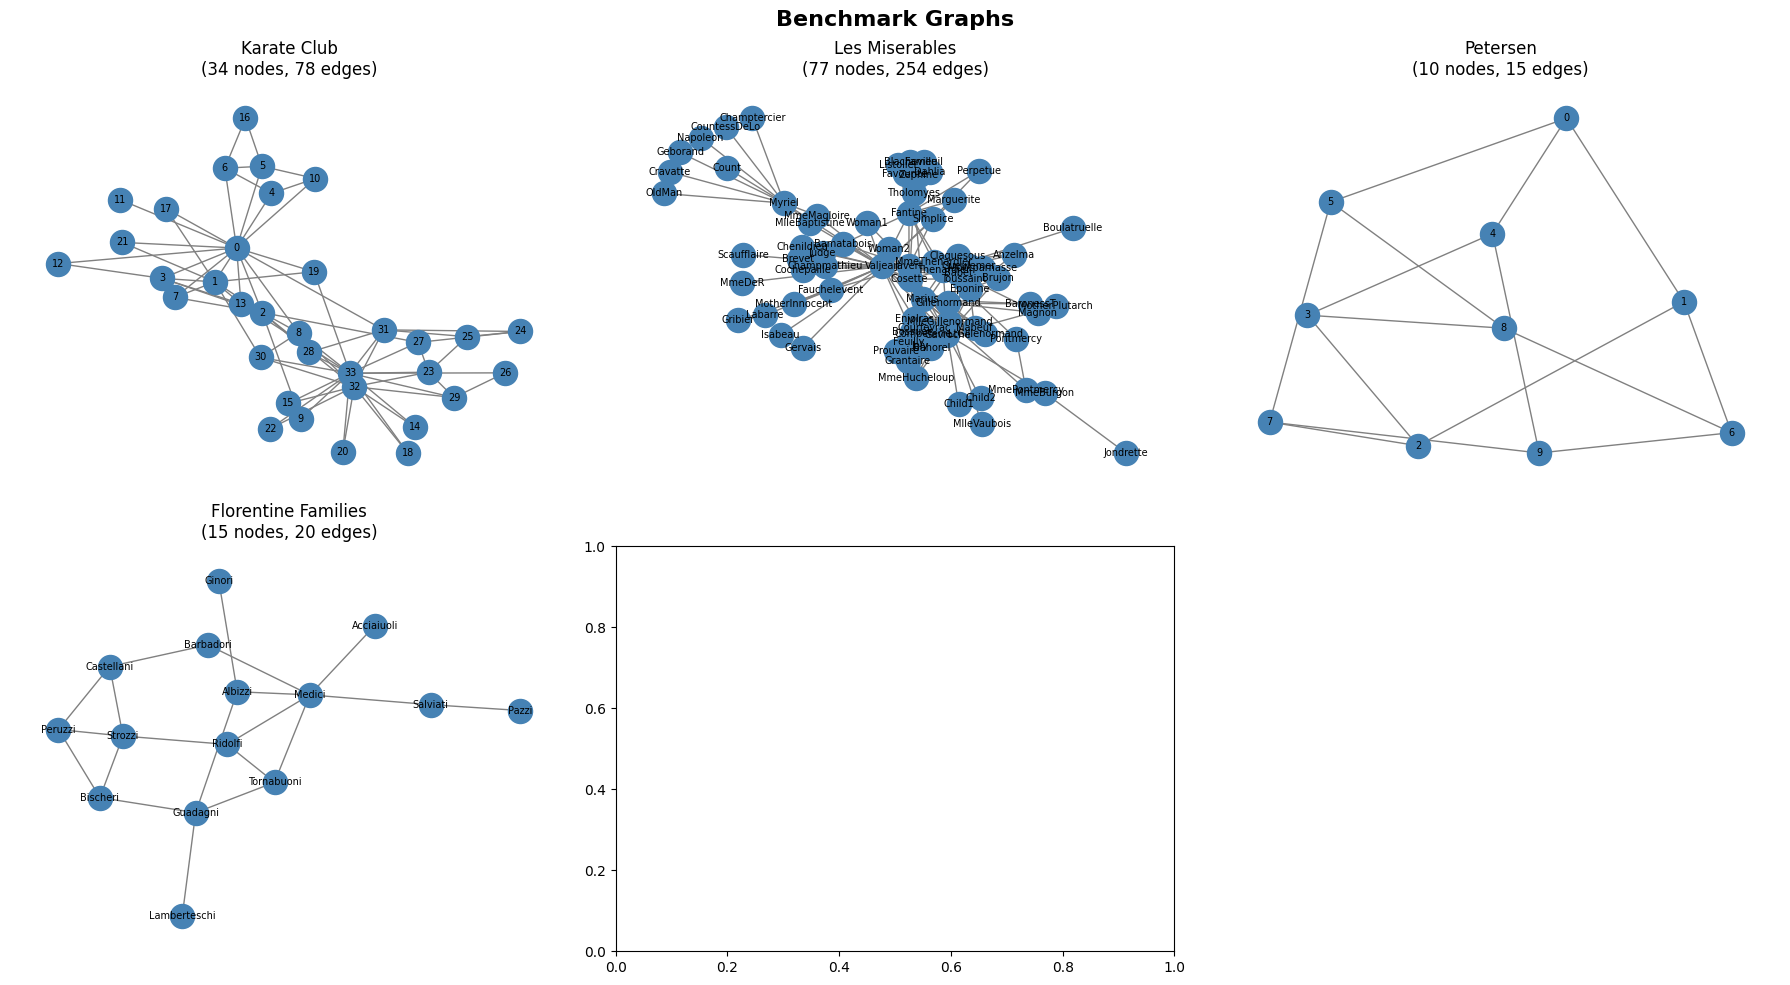

In [4]:
names   = list(graphs.keys())
formats = list(next(iter(corpus.values())).keys())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, G) in enumerate(graphs.items()):
    ax = axes[i]
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=ax, with_labels=True,
            node_color="steelblue", edge_color="gray",
            node_size=300, font_size=7)
    ax.set_title(f"{name}\n({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")

axes[-1].set_visible(False)
plt.suptitle("Benchmark Graphs", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
def get_descriptions_for(corpus, graph_name):
    if graph_name not in corpus:
        raise KeyError(f"'{graph_name}' not found. Available: {list(corpus.keys())}")
    return corpus[graph_name]

descriptions = get_descriptions_for(corpus, "Karate Club")

for fmt, text in descriptions.items():
    print(f"\n{'='*60}")
    print(f"FORMAT: {fmt.upper()}")
    print('='*60)
    print(text[:500] + ("..." if len(text) > 500 else ""))


FORMAT: TEXT
Graph 'Karate Club' has 34 nodes and 78 edges.
There are 16 nodes connected to Node 0: 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31.
There are 9 nodes connected to Node 1: 0, 2, 3, 7, 13, 17, 19, 21, 30.
There are 10 nodes connected to Node 2: 0, 1, 3, 7, 8, 9, 13, 27, 28, 32.
There are 6 nodes connected to Node 3: 0, 1, 2, 7, 12, 13.
There are 3 nodes connected to Node 4: 0, 6, 10.
There are 4 nodes connected to Node 5: 0, 6, 10, 16.
There are 4 nodes connected to Node 6: 0, 4, 5, 16....

FORMAT: ADJACENCY_LIST
N(0) = {1, 10, 11, 12, 13, 17, 19, 2, 21, 3, 31, 4, 5, 6, 7, 8}
N(1) = {0, 13, 17, 19, 2, 21, 3, 30, 7}
N(2) = {0, 1, 13, 27, 28, 3, 32, 7, 8, 9}
N(3) = {0, 1, 12, 13, 2, 7}
N(4) = {0, 10, 6}
N(5) = {0, 10, 16, 6}
N(6) = {0, 16, 4, 5}
N(7) = {0, 1, 2, 3}
N(8) = {0, 2, 30, 32, 33}
N(9) = {2, 33}
N(10) = {0, 4, 5}
N(11) = {0}
N(12) = {0, 3}
N(13) = {0, 1, 2, 3, 33}
N(14) = {32, 33}
N(15) = {32, 33}
N(16) = {5, 6}
N(17) = {0, 1}
N(18) = {32, 33}
N(19) = {0,

In [6]:
import json
import time
from graphs import load_graphs, ground_truth
from llm import GroqLLM, QUERIES

with open("results/graphs_translation.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)

graphs  = load_graphs()
gt      = ground_truth(graphs)
llm     = GroqLLM()
results = {}

for graph_name, formats in corpus.items():
    print(f"\n▶ {graph_name}")
    G      = graphs[graph_name]
    nodes  = list(G.nodes())
    n0     = nodes[0]
    n1     = nodes[3] if len(nodes) > 3 else nodes[-1]
    results[graph_name] = {}

    for fmt, description in formats.items():
        print(f"  ├─ {fmt}")
        results[graph_name][fmt] = {}
        for query_name, question in QUERIES.items():
            try:
                raw   = llm.ask(description, question, first_node=n0, fourth_node=n1)
                parts = raw.split("###ANSWER###")
                results[graph_name][fmt][query_name] = {
                    "reasoning":    parts[0].strip(),
                    "answer":       parts[1].strip() if len(parts) > 1 else raw.strip(),
                    "ground_truth": str(gt[graph_name][query_name]),
                }
                time.sleep(3)  # avoid token rate limit
            except Exception as e:
                err = str(e)
                print(f"    ⚠ {query_name}: {err[:80]}")
                results[graph_name][fmt][query_name] = {"error": err}
                if "429" in err:
                    print("      Rate limit hit — waiting 60s...")
                    time.sleep(60)
        print(f"  ✓ {fmt} done")

    # save after each graph so you don't lose progress on crash
    with open("results/llm_responses.json", "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    print(f" saved checkpoint")

print("\nDone → results/llm_responses.json")


▶ Karate Club
  ├─ text
  ✓ text done
  ├─ adjacency_list
  ✓ adjacency_list done
  ├─ edge_list
  ✓ edge_list done
  ├─ cypher
  ✓ cypher done
  ├─ gml


KeyboardInterrupt: 

In [ ]:
from evaluate import evaluate

eval_results = evaluate(
    results_path="results/llm_responses.json",
    output_path="results/evaluation.json"
)


EVALUATION SUMMARY
Correct : 1/1  (100.0%)
Errors  : 39

────────────────────────────────────────────────────────────
Graph                     Query                Result
────────────────────────────────────────────────────────────
Karate Club               node_count           CORRECT
Karate Club               edge_count           ERROR
Karate Club               neighbors            ERROR
Karate Club               degree               ERROR
Karate Club               shortest_path        ERROR
Karate Club               clustering           ERROR
Karate Club               diameter             ERROR
Karate Club               density              ERROR
Karate Club               is_connected         ERROR
Karate Club               cycle                ERROR
Les Miserables            node_count           ERROR
Les Miserables            edge_count           ERROR
Les Miserables            neighbors            ERROR
Les Miserables            degree               ERROR
Les Miserables        